### Test migration history reconstruction on ovarian cancer data

In [1]:
import sys
import os
from metient.util.globals import *
from metient.metient import *
import matplotlib

matplotlib.rcParams['figure.figsize'] = [3, 3]
      
MCPHERSON_DATA_DIR = os.path.join(os.getcwd(),'metient/data', 'mcpherson_ovarian_2016')               

OUTPUT_DIR = os.path.join(MCPHERSON_DATA_DIR, "metient_outputs", "solve_polys")
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    
PATIENT_IDS = [1,2,3,4,7,9,10]
PATIENT_IDS = [7]

print_config = PrintConfig(visualize=True)

mut_trees_fns = [os.path.join(MCPHERSON_DATA_DIR, f"patient{patient_id}_tree.txt") for patient_id in PATIENT_IDS]
ref_var_fns = [os.path.join(MCPHERSON_DATA_DIR, f"patient{patient_id}_SNVs.tsv") for patient_id in PATIENT_IDS]
run_names = [f"{pid}_calibrate" for pid in PATIENT_IDS]

/lila/home/koyyald/mambaforge/envs/met/lib/python3.8/site-packages/torch/__init__.py:614: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:451.)
  _C._set_default_tensor_type(t)


In [2]:
MSK_MET_FREQ_FILE = '/data/morrisq/divyak/projects/metient/data/msk_met/msk_met_freq_by_cancer_type.csv'

MAPPINGS = [
	# Patient 1
	{
		'Right Ovary':'Ovary',
		'Left Ovary':'Ovary',
		'Left Fallopian Tube':'Female Genital',
		'Right Fallopian Tube':'Female Genital',
		'Omentum':'Intra-Abdominal',
		'Appendix':'Bowel',
		'Small Bowel':'Bowel',
	},
	# Patient 2
	{
		'Omentum':'Intra-Abdominal',
	},
	# Patient 3
	{
		'Right Ovary':'Ovary',
		'Left Ovary':'Ovary',
		'Adnexa':'Female Genital',
		'Cul de Sac':'Intra-Abdominal',
		'Left Fallopian Tube Fimbriae':'Female Genital',
		'Omentum':'Intra-Abdominal',
		'Right Fallopian Tube':'Female Genital',
		'Sigmoid Colon Deposit':'Bowel',
	},
	# Patient 4
	{
		'Left Ovary Surface':'Ovary',
		'Right Ovary':'Ovary',
		'Left Pelvic Sidewall':'Bone',
		'Right Pelvic Sidewall':'Bone',
	},
	# Patient 7
	{
		'Right Ovary':'Ovary',
		'Left Ovary':'Ovary',
		'Right Uterosacral':'Unspecified',
		'Bowel Implant':'Bowel',
		'Brain Metastasis':'CNS/Brain',
		'Righ Pelvic Mass':'Distant LN',#??
	},
	# Patient 9
	{
		'Right Ovary':'Ovary',
		'Left Ovary':'Ovary',
		'Omentum':'Intra-Abdominal',
	},
	# Patient 10
	{
		'Left Fallopian Tube':'Female Genital',
		'Omentum':'Intra-Abdominal',
	}
]

import pandas as pd

def get_metastasis_frequencies(site_mappings, met_freq_file):
    """
    Get normalized metastasis frequencies for each anatomical site from MSK data
    
    Args:
        site_mappings: List of dictionaries mapping sample sites to standardized categories
        met_freq_file: Path to CSV file containing metastasis frequencies
        
    Returns:
        List of dictionaries containing normalized frequencies for each patient's sites
    """
    # Read metastasis frequency data
    met_freq_df = pd.read_csv(met_freq_file)
    ovarian_freq = met_freq_df[met_freq_df['Cancer Type'] == 'Ovarian Cancer']


    # Get frequencies for our site categories
    O_by_patient = []
    for mapping in site_mappings:
        O = {}
        for mcpherson_site, msk_site in mapping.items():
            freq = float(ovarian_freq[msk_site].iloc[0])
            O[mcpherson_site] = freq
			
        # Normalize frequencies
        total = sum(O.values())
        print("\n",O)
        if total > 0:
            O = {k:v/total for k,v in O.items()}
        print(O)
        O_by_patient.append(O)
        
    return O_by_patient

Os = get_metastasis_frequencies(MAPPINGS, MSK_MET_FREQ_FILE)


 {'Right Ovary': 226.0, 'Left Ovary': 226.0, 'Left Fallopian Tube': 793.0, 'Right Fallopian Tube': 793.0, 'Omentum': 1013.0, 'Appendix': 773.0, 'Small Bowel': 773.0}
{'Right Ovary': 0.04916249728083533, 'Left Ovary': 0.04916249728083533, 'Left Fallopian Tube': 0.17250380683054164, 'Right Fallopian Tube': 0.17250380683054164, 'Omentum': 0.22036110506852294, 'Appendix': 0.16815314335436155, 'Small Bowel': 0.16815314335436155}

 {'Omentum': 1013.0}
{'Omentum': 1.0}

 {'Right Ovary': 226.0, 'Left Ovary': 226.0, 'Adnexa': 793.0, 'Cul de Sac': 1013.0, 'Left Fallopian Tube Fimbriae': 793.0, 'Omentum': 1013.0, 'Right Fallopian Tube': 793.0, 'Sigmoid Colon Deposit': 773.0}
{'Right Ovary': 0.04014209591474245, 'Left Ovary': 0.04014209591474245, 'Adnexa': 0.1408525754884547, 'Cul de Sac': 0.17992895204262876, 'Left Fallopian Tube Fimbriae': 0.1408525754884547, 'Omentum': 0.17992895204262876, 'Right Fallopian Tube': 0.1408525754884547, 'Sigmoid Colon Deposit': 0.13730017761989344}

 {'Left Ovary 

Saving results to /lila/data/morrisq/divyak/projects/metient/data/mcpherson_ovarian_2016/metient_outputs/solve_polys/calibrate
Overwriting existing directory at /lila/data/morrisq/divyak/projects/metient/data/mcpherson_ovarian_2016/metient_outputs/solve_polys/calibrate

*** Calibrating for patient: 7_calibrate ***
Multiple primaries given. Running each as primary
Using GPU
Using organotropism frequencies {'Right Ovary': 0.08410867138072199, 'Left Ovary': 0.08410867138072199, 'Right Uterosacral': 0.3688128023818385, 'Bowel Implant': 0.28768142910308897, 'Brain Metastasis': 0.020468924451060664, 'Righ Pelvic Mass': 0.1548195013025679}
O: tensor([0.00, 0.08, 0.37, 0.29, 0.02, 0.15])
Tumor samples: ['Left Ovary', 'Right Ovary', 'Right Uterosacral', 'Bowel Implant', 'Brain Metastasis', 'Righ Pelvic Mass']
input_T.shape torch.Size([5, 5])
Using sparse T: False


  0%|          | 0/2800 [00:00<?, ?it/s]/lila/home/koyyald/mambaforge/envs/met/lib/python3.8/site-packages/torch/optim/lr_scheduler.py:136: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "
100%|█████████▉| 2795/2800 [00:13<00:00, 241.04it/s]

Number of final solutions: 4
Using GPU
Using organotropism frequencies {'Right Ovary': 0.08410867138072199, 'Left Ovary': 0.08410867138072199, 'Right Uterosacral': 0.3688128023818385, 'Bowel Implant': 0.28768142910308897, 'Brain Metastasis': 0.020468924451060664, 'Righ Pelvic Mass': 0.1548195013025679}
O: tensor([0.08, 0.00, 0.37, 0.29, 0.02, 0.15])
Tumor samples: ['Left Ovary', 'Right Ovary', 'Right Uterosacral', 'Bowel Implant', 'Brain Metastasis', 'Righ Pelvic Mass']
input_T.shape torch.Size([5, 5])
Using sparse T: False


100%|██████████| 2800/2800 [00:22<00:00, 126.61it/s]
/lila/home/koyyald/mambaforge/envs/met/lib/python3.8/site-packages/torch/optim/lr_scheduler.py:136: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "
100%|█████████▉| 2798/2800 [00:12<00:00, 245.23it/s]

Number of final solutions: 3
Using GPU
Using organotropism frequencies {'Right Ovary': 0.08410867138072199, 'Left Ovary': 0.08410867138072199, 'Right Uterosacral': 0.3688128023818385, 'Bowel Implant': 0.28768142910308897, 'Brain Metastasis': 0.020468924451060664, 'Righ Pelvic Mass': 0.1548195013025679}
O: tensor([0.08, 0.08, 0.00, 0.29, 0.02, 0.15])
Tumor samples: ['Left Ovary', 'Right Ovary', 'Right Uterosacral', 'Bowel Implant', 'Brain Metastasis', 'Righ Pelvic Mass']
input_T.shape torch.Size([5, 5])
Using sparse T: False


100%|██████████| 2800/2800 [00:19<00:00, 145.55it/s]
/lila/home/koyyald/mambaforge/envs/met/lib/python3.8/site-packages/torch/optim/lr_scheduler.py:136: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "
100%|█████████▉| 2799/2800 [00:12<00:00, 243.30it/s]

Number of final solutions: 1
pt_idx_to_denom {0: 2}
new pt weights [2.0, 2.0, 0]
full_run_name_to_calibration_weight {'7_calibrate_Left Ovary': 2.0, '7_calibrate_Right Ovary': 2.0, '7_calibrate_Right Uterosacral': 0}
Calibrating parsimony weights to match both genetic distance and organotropism distributions
Calibrating to 2 patients


























































































































































































































































































































































































































































































































































































































































































<Figure size 300x300 with 0 Axes>

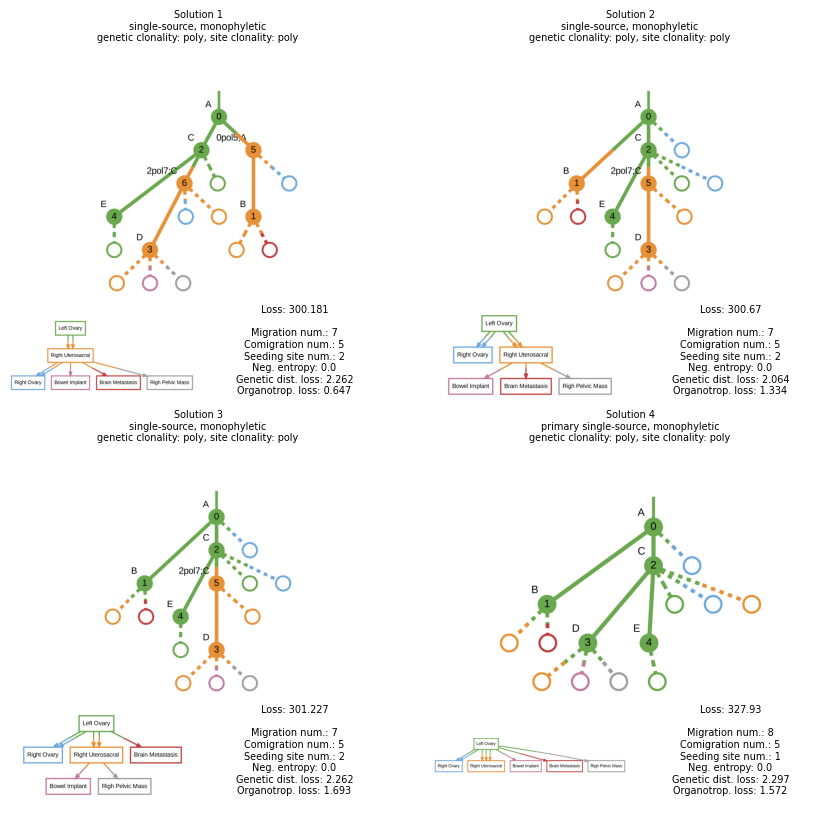

100%|██████████| 2800/2800 [00:28<00:00, 243.30it/s]

7_calibrate_Right Ovary


<Figure size 300x300 with 0 Axes>

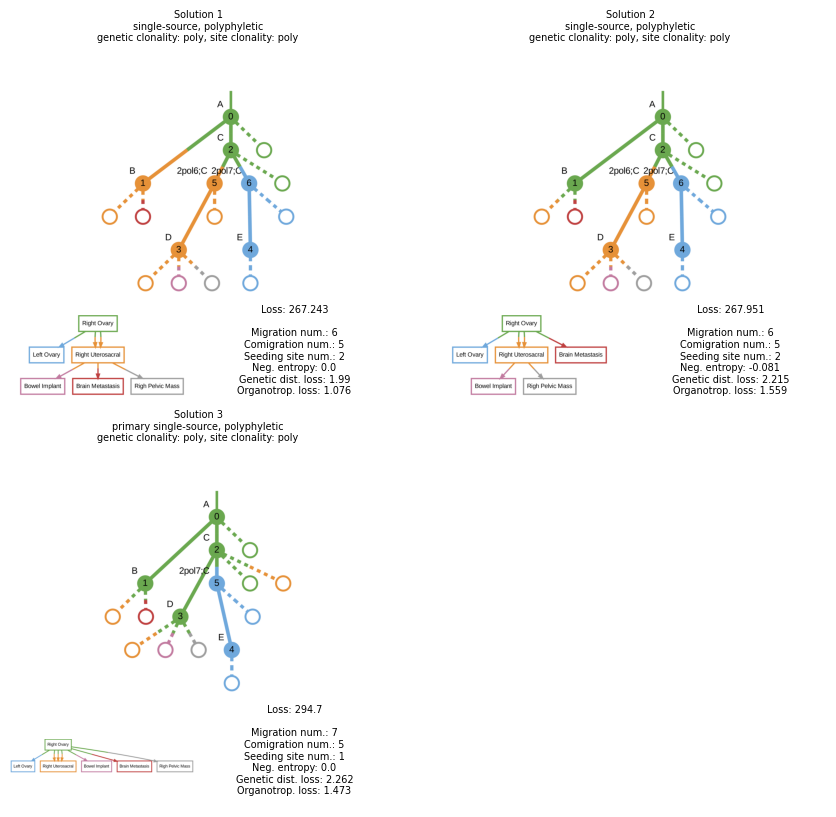

7_calibrate_Right Uterosacral


<Figure size 300x300 with 0 Axes>

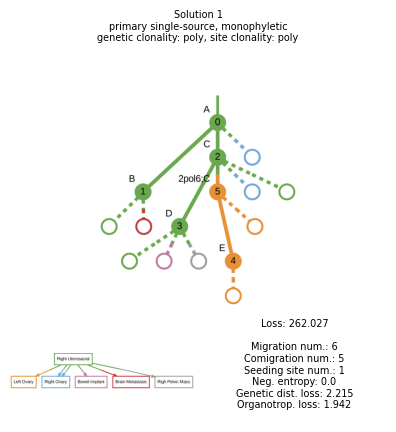

[0.6619155406951904, 0.21195442974567413, 0.12613001465797424]

In [3]:
# Os = [Os[0], Os[2], Os[4]]
Os = [Os[4]]
calibrate_label_clone_tree(mut_trees_fns, ref_var_fns, print_config, OUTPUT_DIR, run_names,"both",
                           Os=Os, solve_polytomies=True, sample_size=4096)

### Run all patients in calibrate mode

In [ ]:
%%prun
calibrate_label_clone_tree(mut_trees_fns, ref_var_fns, print_config, OUTPUT_DIR, run_names,
                           solve_polytomies=True, sample_size=2048)


### Run all patients in calibrate mode without solving for polytomies

In [4]:
calibrate_label_clone_tree(mut_trees_fns, ref_var_fns, print_config, OUTPUT_DIR, run_names, 
                           solve_polytomies=False,batch_size=1024)

### Recreating McPherson predicted trees (for easier visualization comparison)

In [22]:
from metient.lib import vertex_labeling as vert
from metient.util import data_extraction_util as dutil

OUTPUT_DIR = os.path.join(MCPHERSON_DATA_DIR, "metient_outputs", "evaluate_testing")
patient_id = 1
weights = Weights(mig=100, comig=50, seed_site=1,gen_dist=1)
T = dutil.get_adjacency_matrix_from_txt_edge_list(os.path.join(MCPHERSON_DATA_DIR, f"patient{patient_id}_tree.txt"))

ref_var_fn = os.path.join(MCPHERSON_DATA_DIR, f"patient{patient_id}_SNVs.tsv")
run_name = f"{patient_id}_evaluate"
# evaluate_label_clone_tree(mut_trees_fn, ref_var_fn, weights, print_config, OUTPUT_DIR, run_name,
#                           bias_weights=True, solve_polytomies=False)

vert.get_migration_history(T, ref_var_fn,"Right Ovary", weights, print_config, OUTPUT_DIR, run_name,
                           estimate_observed_clones=False,O=None, needs_pruning=False)

In [23]:
from metient.util import plotting_util as plutil
import torch
from metient.util.globals import *

T = torch.zeros((26,26))
edges = [(0,1),(0,2),(0,3),(3,4),(3,5),(5,6),(0,7),(0,8),(1,9),(1,10),(1,11),(2,12),(2,13),
         (3,14),(3,15),(3,16),(3,17),(3,18),(3,19),(3,20),(4,21),(5,22),(5,23),(5,24),(6,25)]
for edge in edges:
    T[edge[0],edge[1]] = 1
sites = ['Left Ovary', 'Right Ovary', 'Adnexa', 'Cul de Sac', 'Left Fallopian Tube Fimbriae', 'Omentum', 'Right Fallopian Tube', 'Sigmoid Colon Deposit']
idx_to_category = {0:0,1:5,2:0,3:0,4:1,5:0,6:2,7:0,8:6,9:3,10:5,11:7,12:0,13:7,14:0,15:1,16:3,17:4,18:5,19:6,20:7,21:1,22:0,23:4,24:5,25:2}
num_categories = len(sites)
V = torch.zeros((num_categories,len(idx_to_category)))
for i, category in idx_to_category.items():
    V[category,i] = 1
plutil.plot_migration_graph(V,T,sites,DEFAULT_COLORS,'Left Ovary')
